# 📊 Univariate Analysis

> **Folder:** `02_Exploratory_Data_Analysis / Univariate_Analysis`  
> **Notebook:** `univariate_analysis.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand the difference between **numerical and categorical** variables
- Compute and interpret **descriptive statistics** (mean, median, std, skewness, kurtosis)
- Apply the full suite of **univariate visualizations** — histogram, KDE, box plot, violin, Q-Q, ECDF
- Analyze categorical variables using **frequency tables, bar charts, and count plots**
- Build a complete **automated EDA report** for any dataset

---

## 📚 Techniques Covered

| # | Technique | Variable Type |
|---|-----------|:--------------:|
| 1 | Descriptive Statistics Summary | Numerical |
| 2 | Histogram + KDE | Numerical |
| 3 | Box Plot | Numerical |
| 4 | Violin Plot | Numerical |
| 5 | Q-Q Plot (Normality Check) | Numerical |
| 6 | ECDF | Numerical |
| 7 | Skewness & Kurtosis Report | Numerical |
| 8 | Frequency Table | Categorical |
| 9 | Bar Chart + Count Plot | Categorical |
| 10 | Pie / Donut Chart | Categorical |
| 11 | Automated Full EDA Report | Both |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Color palette ─────────────────────────────────────────────────────────
COLORS = {
    'primary'   : '#2E86AB',
    'secondary' : '#E84855',
    'accent'    : '#3BB273',
    'warning'   : '#F18F01',
    'purple'    : '#7B2D8B',
    'palette'   : ['#2E86AB','#E84855','#3BB273','#F18F01','#7B2D8B','#F4D35E'],
}

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Inspect Dataset

In [2]:
# ── Synthetic dataset with diverse feature types ──────────────────────────
np.random.seed(42)
n = 500

df = pd.DataFrame({
    # Numerical — continuous
    'Age'        : np.random.randint(18, 70, n),
    'Salary'     : np.random.randint(25_000, 180_000, n),
    'Score'      : np.random.normal(65, 15, n).clip(0, 100),
    'Income'     : np.random.exponential(50_000, n),          # right-skewed
    'Savings'    : np.random.normal(10_000, 3_000, n),        # roughly normal
    'Debt'       : np.concatenate([
                       np.random.normal(5_000, 1_000, n - 20),
                       np.random.normal(80_000, 5_000, 20)    # injected outliers
                   ]),
    # Numerical — discrete
    'Num_Products': np.random.randint(1, 15, n),
    # Categorical — nominal
    'City'       : np.random.choice(['London','Paris','Berlin','Tokyo','Sydney'], n,
                                     p=[0.35, 0.25, 0.20, 0.12, 0.08]),
    'Gender'     : np.random.choice(['Male','Female','Non-Binary'], n,
                                     p=[0.48, 0.48, 0.04]),
    # Categorical — ordinal
    'Education'  : np.random.choice(
                       ['High School',"Bachelor's",'Master\'s','PhD'], n,
                       p=[0.25, 0.40, 0.25, 0.10]),
    # Target
    'Churn'      : np.random.choice([0, 1], n, p=[0.80, 0.20]),
})

# Inject a few missing values
df.loc[np.random.choice(df.index, 20, replace=False), 'Salary']  = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), 'City']    = np.nan

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
df.head()

Shape   : (500, 11)
Columns : ['Age', 'Salary', 'Score', 'Income', 'Savings', 'Debt', 'Num_Products', 'City', 'Gender', 'Education', 'Churn']


,Age,Salary,Score,Income,Savings,Debt,Num_Products,City,Gender,Education,Churn
0,56,159415.0000,72.9788,44937.0811,11980.0318,2800.3893,6,Paris,Male,High School,0
1,69,169572.0000,75.4453,43305.4220,14305.7411,3287.5605,10,Sydney,Male,High School,0
2,46,54375.0000,72.7419,54327.4589,10488.0100,6517.5201,8,Paris,Male,Master's,0
3,32,165734.0000,72.1324,5005.4668,7431.0803,6695.3295,4,Sydney,Male,Bachelor's,0
4,60,41964.0000,56.3937,52795.3508,9464.1701,4893.3487,2,Tokyo,Female,Master's,0


In [3]:
# ── First look at data types & missing values ─────────────────────────────
info_df = pd.DataFrame({
    'Dtype'         : df.dtypes,
    'Non-Null Count': df.count(),
    'Missing'       : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2),
    'Unique Values' : df.nunique(),
})
print('Dataset Overview:')
info_df

Dataset Overview:


,Dtype,Non-Null Count,Missing,Missing %,Unique Values
Age,int64,500,0,0.0000,52
Salary,float64,480,20,4.0000,479
Score,float64,500,0,0.0000,489
Income,float64,500,0,0.0000,500
Savings,float64,500,0,0.0000,500
Debt,float64,500,0,0.0000,500
Num_Products,int64,500,0,0.0000,14
City,object,485,15,3.0000,5
Gender,object,500,0,0.0000,3
Education,object,500,0,0.0000,4


In [4]:
# ── Separate numerical and categorical columns ────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical   ({len(num_cols)}): {num_cols}')
print(f'Categorical ({len(cat_cols)}): {cat_cols}')

Numerical   (8): ['Age', 'Salary', 'Score', 'Income', 'Savings', 'Debt', 'Num_Products', 'Churn']
Categorical (3): ['City', 'Gender', 'Education']


---
## 1️⃣ Descriptive Statistics — Numerical Variables

> **`df.describe()`** gives count, mean, std, min, quartiles, and max in one call.
>
> ✅ Always the **first step** for numerical EDA.

In [5]:
# ── Extended describe with skewness & kurtosis ────────────────────────────
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(4)
desc['kurtosis'] = df[num_cols].kurtosis().round(4)
desc['IQR']      = (df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)).round(2)
desc['CV %']     = ((df[num_cols].std() / df[num_cols].mean()) * 100).round(2)

print('Extended Descriptive Statistics:')
desc

Extended Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR,CV %
Age,500.0000,44.2200,15.0361,18.0000,32.0000,45.0000,57.0000,69.0000,-0.1127,-1.1070,25.0000,34.0000
Salary,480.0000,101350.6292,45169.6147,25235.0000,63385.7500,102016.0000,139136.7500,179865.0000,-0.0015,-1.2237,75751.0000,44.5700
Score,500.0000,66.6527,15.9497,23.2305,55.8159,66.0568,77.4350,100.0000,0.0378,-0.3666,21.6200,23.9300
Income,500.0000,47101.3504,46282.2300,16.6281,13960.0425,33394.0728,63396.6242,269967.5927,1.8079,3.7592,49436.5800,98.2600
Savings,500.0000,9980.8256,2854.6743,-54.8316,8137.7464,10084.8961,11866.1261,18020.5329,-0.1064,0.2259,3728.3800,28.6000
Debt,500.0000,8041.6166,14611.4384,1613.1862,4379.6426,5162.7383,5873.4173,86813.0851,4.7194,20.6205,1493.7700,181.7000
Num_Products,500.0000,7.7060,4.0955,1.0000,4.0000,8.0000,11.0000,14.0000,-0.0638,-1.2659,7.0000,53.1500
Churn,500.0000,0.1860,0.3895,0.0000,0.0000,0.0000,0.0000,1.0000,1.6188,0.6230,0.0000,209.4100


In [6]:
# ── Skewness Interpretation Table ────────────────────────────────────────
skew_report = pd.DataFrame({
    'Feature'  : num_cols,
    'Skewness' : [round(df[c].skew(), 4) for c in num_cols],
})
skew_report['Interpretation'] = skew_report['Skewness'].apply(
    lambda s: '⬅️ Negatively Skewed' if s < -0.5
              else ('✅ Approximately Symmetric' if abs(s) <= 0.5
              else '➡️ Positively Skewed')
)
skew_report['Recommended Action'] = skew_report['Skewness'].apply(
    lambda s: 'Log / Sqrt Transform' if s > 1
              else ('Reflect + Log Transform' if s < -1
              else 'No transform needed')
)
print('\nSkewness Report:')
skew_report


Skewness Report:


,Feature,Skewness,Interpretation,Recommended Action
0,Age,-0.1127,✅ Approximately Symmetric,No transform needed
1,Salary,-0.0015,✅ Approximately Symmetric,No transform needed
2,Score,0.0378,✅ Approximately Symmetric,No transform needed
3,Income,1.8079,➡️ Positively Skewed,Log / Sqrt Transform
4,Savings,-0.1064,✅ Approximately Symmetric,No transform needed
5,Debt,4.7194,➡️ Positively Skewed,Log / Sqrt Transform
6,Num_Products,-0.0638,✅ Approximately Symmetric,No transform needed
7,Churn,1.6188,➡️ Positively Skewed,Log / Sqrt Transform


---
## 2️⃣ Histogram + KDE — Distribution Shape

> Histogram bins raw counts; KDE smooths them into a continuous density curve.
>
> ✅ Use both together for the fullest picture of a feature's distribution.

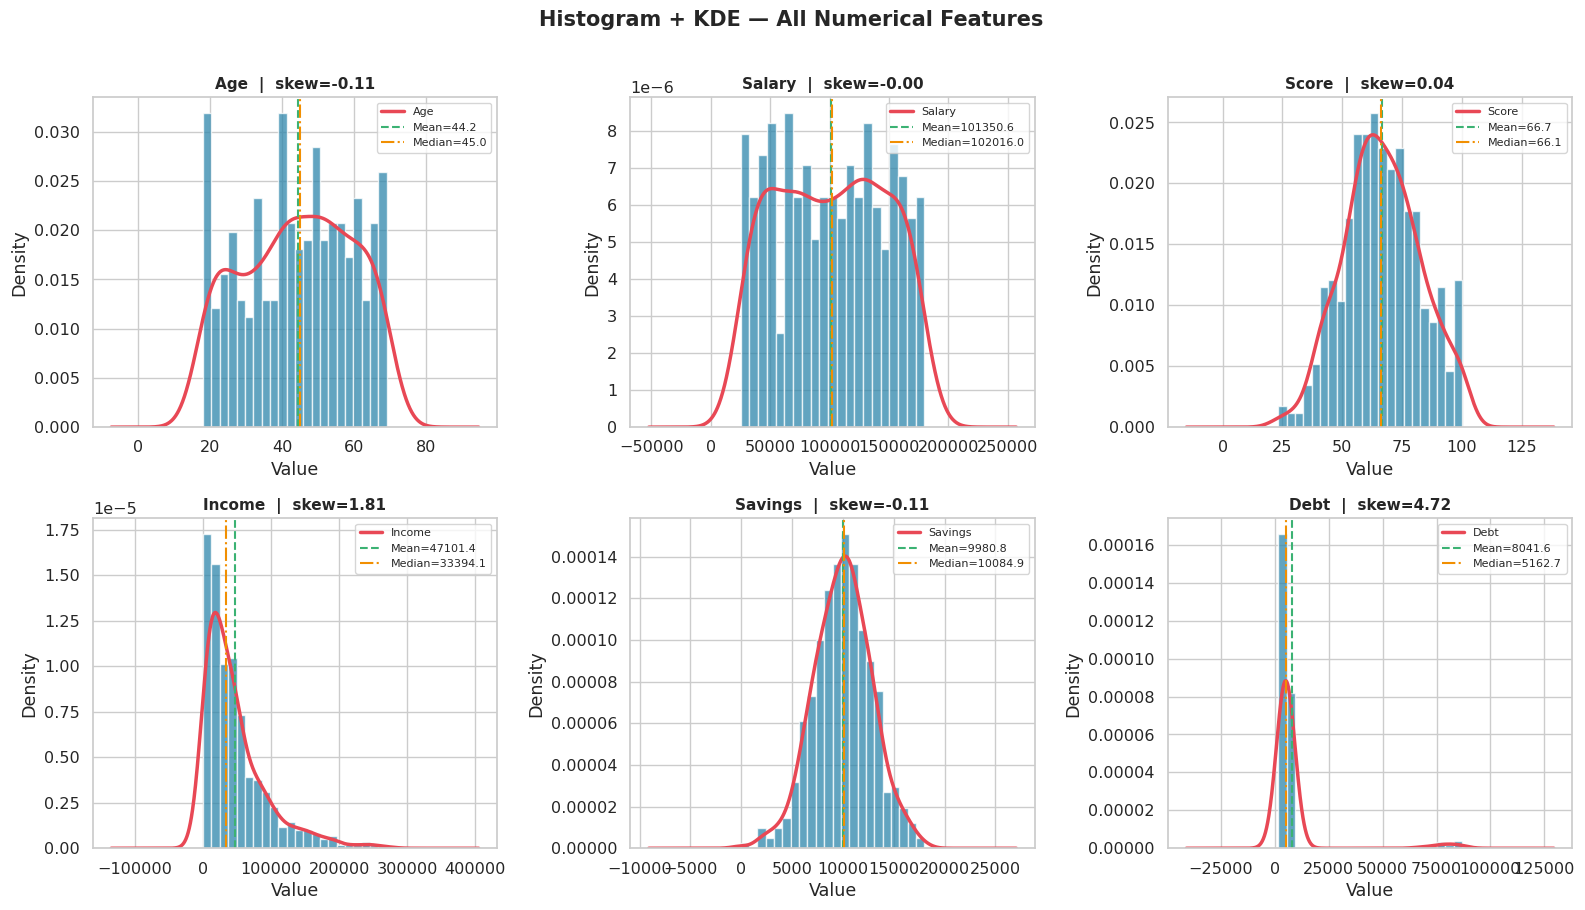

In [7]:
# ── Histogram + KDE grid for all numerical features ───────────────────────
cols_to_plot = ['Age', 'Salary', 'Score', 'Income', 'Savings', 'Debt']
n_cols = 3
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    data = df[col].dropna()
    ax.hist(data, bins=int(np.sqrt(len(data))),
            color=COLORS['primary'], edgecolor='white', alpha=0.75, density=True)
    data.plot.kde(ax=ax, color=COLORS['secondary'], linewidth=2.5)
    ax.axvline(data.mean(),   color=COLORS['accent'],  linestyle='--',
               linewidth=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color=COLORS['warning'], linestyle='-.',
               linewidth=1.5, label=f'Median={data.median():.1f}')
    ax.set_title(f'{col}  |  skew={data.skew():.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# Hide unused subplots
for ax in axes[len(cols_to_plot):]:
    ax.set_visible(False)

plt.suptitle('Histogram + KDE — All Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3️⃣ Box Plot — Outlier Detection

> Shows Min, Q1, Median, Q3, Max and flags points beyond 1.5 × IQR as outliers.
>
> ✅ The fastest visual tool to spot outliers across multiple features at once.

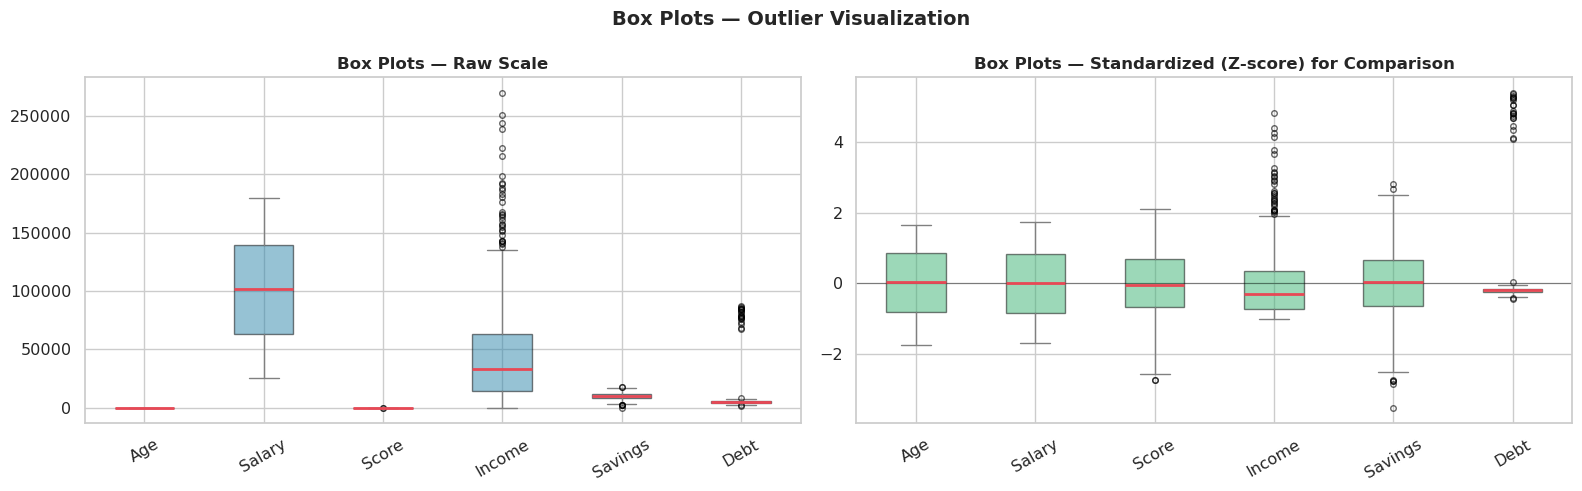

In [8]:
# ── Standardized box plots (z-score scaled for fair comparison) ───────────
df_scaled = df[cols_to_plot].apply(lambda x: (x - x.mean()) / x.std())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw scale
df[cols_to_plot].boxplot(
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['primary'], alpha=0.5),
    medianprops=dict(color=COLORS['secondary'], linewidth=2),
    flierprops=dict(marker='o', color=COLORS['secondary'], markersize=4, alpha=0.6),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)
axes[0].set_title('Box Plots — Raw Scale', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Standardized scale
df_scaled.boxplot(
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['accent'], alpha=0.5),
    medianprops=dict(color=COLORS['secondary'], linewidth=2),
    flierprops=dict(marker='o', color=COLORS['secondary'], markersize=4, alpha=0.6),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)
axes[1].set_title('Box Plots — Standardized (Z-score) for Comparison',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='black', linewidth=0.8, alpha=0.4)

plt.suptitle('Box Plots — Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ Violin Plot — Distribution + Summary

> Combines KDE + box plot in one — shows both the **shape** of the distribution
> and key **summary statistics** (median, IQR).
>
> ✅ Best when comparing distributions across groups.

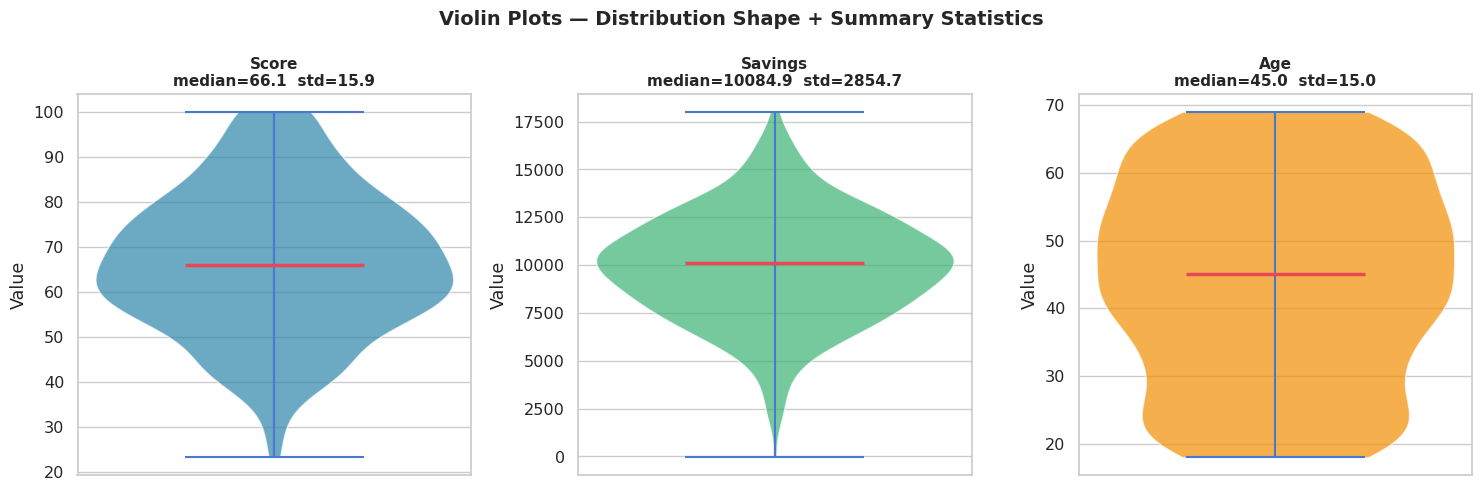

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes,
                           ['Score', 'Savings', 'Age'],
                           [COLORS['primary'], COLORS['accent'], COLORS['warning']]):
    parts = ax.violinplot(
        df[col].dropna(),
        showmedians=True,
        showextrema=True
    )
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color(COLORS['secondary'])
    parts['cmedians'].set_linewidth(2.5)

    ax.set_title(f'{col}\nmedian={df[col].median():.1f}  '
                 f'std={df[col].std():.1f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Value')

plt.suptitle('Violin Plots — Distribution Shape + Summary Statistics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Q-Q Plot — Normality Check

> Plots sample quantiles vs theoretical normal quantiles.
>
> ✅ Points along the diagonal = normally distributed.  
> ❌ Curves away from diagonal = non-normal (skewed or heavy-tailed).

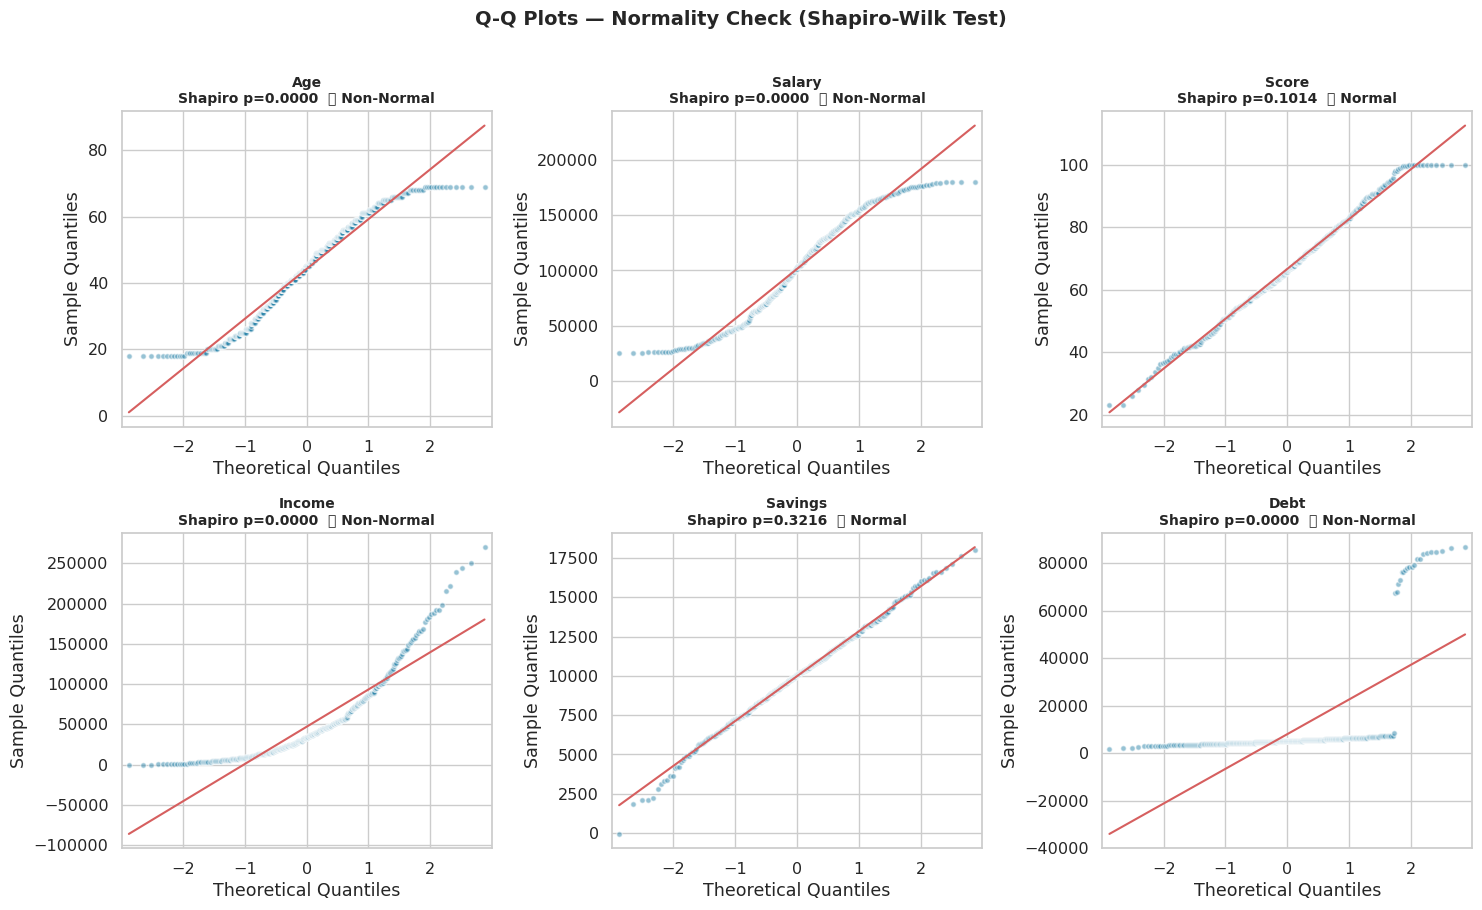

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    data = df[col].dropna()
    sm.qqplot(data, line='s', ax=ax, alpha=0.5,
              markerfacecolor=COLORS['primary'],
              markeredgecolor='white',
              markersize=4)

    # Shapiro-Wilk test (only reliable for n < 5000)
    sample = data.sample(min(300, len(data)), random_state=42)
    stat, p_val = shapiro(sample)
    normal_str = '✅ Normal' if p_val > 0.05 else '❌ Non-Normal'

    ax.set_title(f'{col}\nShapiro p={p_val:.4f}  {normal_str}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.suptitle('Q-Q Plots — Normality Check (Shapiro-Wilk Test)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6️⃣ ECDF — Empirical Cumulative Distribution

> Shows what **proportion of data** falls at or below each value.
>
> ✅ Better than histograms for comparing two distributions directly.

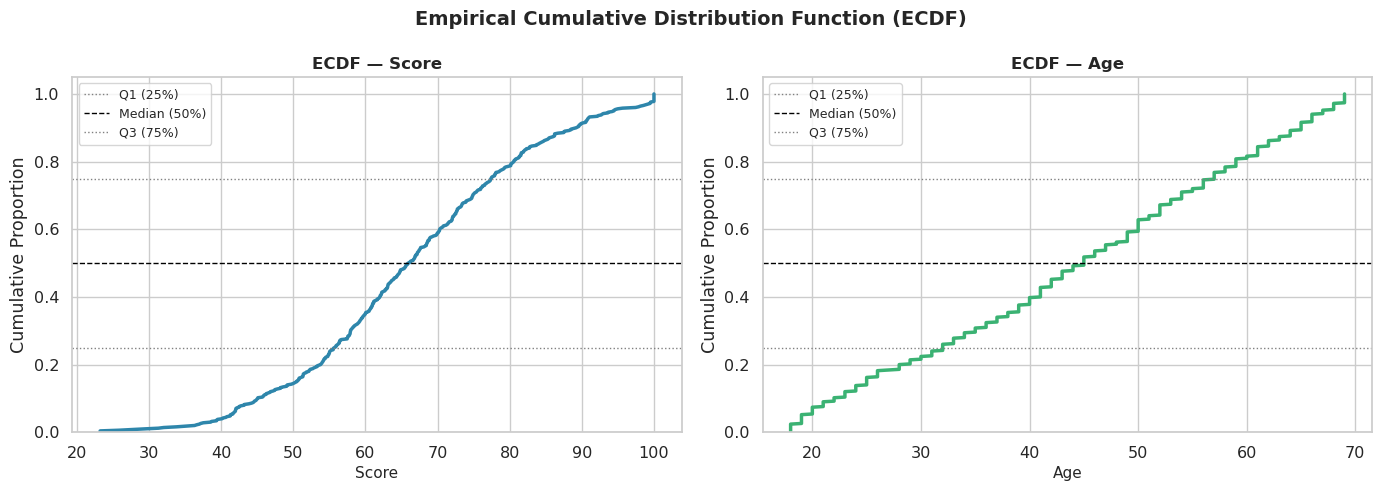

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ECDF for Score
for col, color, ax in [('Score', COLORS['primary'], axes[0]),
                        ('Age',   COLORS['accent'],  axes[1])]:
    data   = df[col].dropna().sort_values()
    ecdf_y = np.arange(1, len(data) + 1) / len(data)
    ax.plot(data, ecdf_y, color=color, linewidth=2.5)
    ax.axhline(0.25, color='gray',  linestyle=':', linewidth=1, label='Q1 (25%)')
    ax.axhline(0.50, color='black', linestyle='--', linewidth=1, label='Median (50%)')
    ax.axhline(0.75, color='gray',  linestyle=':', linewidth=1, label='Q3 (75%)')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Cumulative Proportion')
    ax.set_title(f'ECDF — {col}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

plt.suptitle('Empirical Cumulative Distribution Function (ECDF)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Comparing Distributions: Before vs After Log Transform

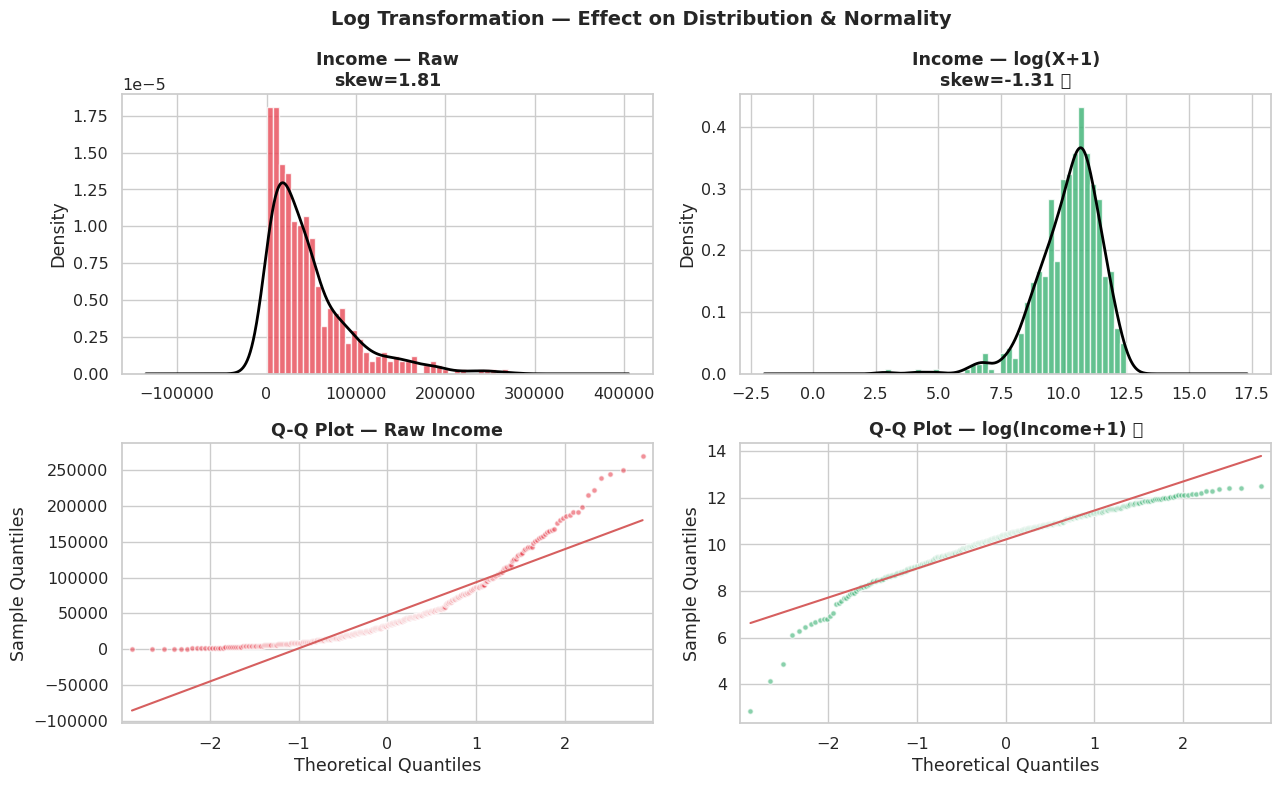

In [12]:
col = 'Income'
income_log = np.log1p(df[col].dropna())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Histogram — before
axes[0, 0].hist(df[col].dropna(), bins=40, color=COLORS['secondary'],
                edgecolor='white', alpha=0.8, density=True)
df[col].dropna().plot.kde(ax=axes[0, 0], color='black', linewidth=2)
axes[0, 0].set_title(f'Income — Raw\nskew={df[col].skew():.2f}', fontweight='bold')

# Histogram — after log
axes[0, 1].hist(income_log, bins=40, color=COLORS['accent'],
                edgecolor='white', alpha=0.8, density=True)
income_log.plot.kde(ax=axes[0, 1], color='black', linewidth=2)
axes[0, 1].set_title(f'Income — log(X+1)\nskew={income_log.skew():.2f} ✅', fontweight='bold')

# Q-Q — before
sm.qqplot(df[col].dropna(), line='s', ax=axes[1, 0],
          markerfacecolor=COLORS['secondary'], markeredgecolor='white',
          markersize=4, alpha=0.6)
axes[1, 0].set_title('Q-Q Plot — Raw Income', fontweight='bold')

# Q-Q — after log
sm.qqplot(income_log, line='s', ax=axes[1, 1],
          markerfacecolor=COLORS['accent'], markeredgecolor='white',
          markersize=4, alpha=0.6)
axes[1, 1].set_title('Q-Q Plot — log(Income+1) ✅', fontweight='bold')

plt.suptitle('Log Transformation — Effect on Distribution & Normality',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Categorical Analysis — Frequency Table

> Always start categorical EDA with **value counts** — understand how many unique
> values exist and how they are distributed.

In [13]:
for col in cat_cols:
    print(f'\n📋 {col} — Frequency Table')
    print('-' * 40)
    freq = df[col].value_counts(dropna=False)
    pct  = df[col].value_counts(normalize=True, dropna=False) * 100
    freq_df = pd.DataFrame({'Count': freq, 'Percentage': pct.round(2)})
    freq_df.index.name = col
    print(freq_df.to_string())
    print(f'  Unique values : {df[col].nunique()}')
    print(f'  Missing       : {df[col].isnull().sum()}')


📋 City — Frequency Table
----------------------------------------
        Count  Percentage
City                     
London    173     34.6000
Paris     111     22.2000
Berlin    105     21.0000
Tokyo      54     10.8000
Sydney     42      8.4000
NaN        15      3.0000
  Unique values : 5
  Missing       : 15

📋 Gender — Frequency Table
----------------------------------------
            Count  Percentage
Gender                       
Male          252     50.4000
Female        224     44.8000
Non-Binary     24      4.8000
  Unique values : 3
  Missing       : 0

📋 Education — Frequency Table
----------------------------------------
             Count  Percentage
Education                     
Bachelor's     196     39.2000
Master's       135     27.0000
High School    127     25.4000
PhD             42      8.4000
  Unique values : 4
  Missing       : 0


---
## 9️⃣ Bar Charts — Categorical Distribution

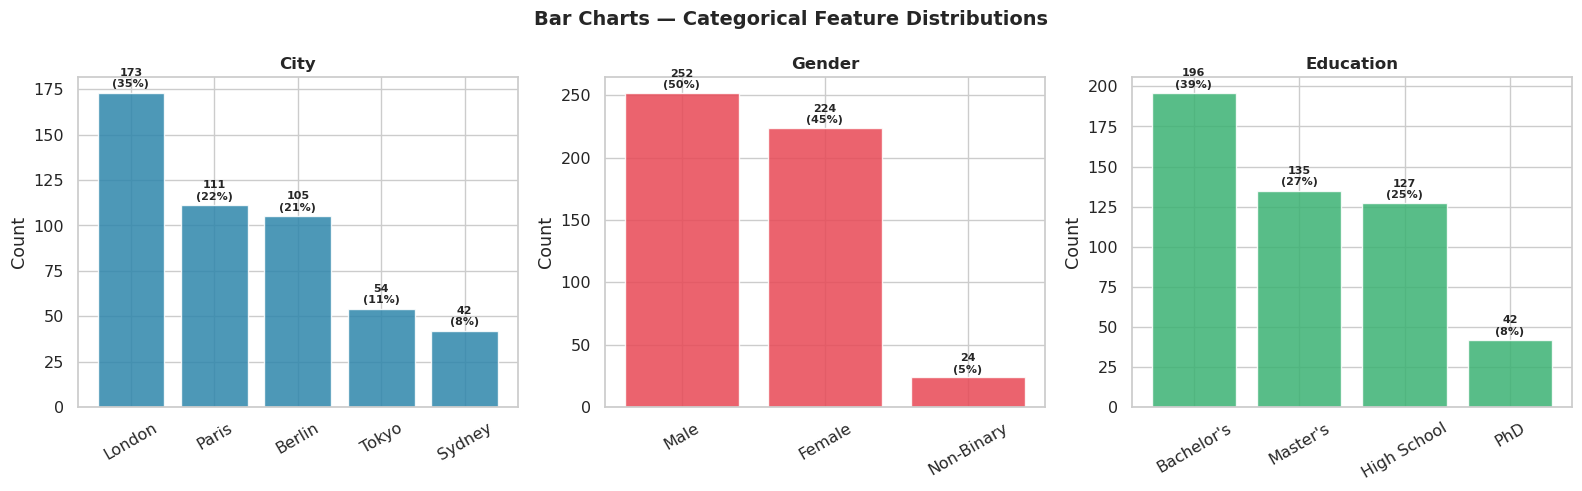

In [14]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))

for ax, col, color in zip(axes, cat_cols, COLORS['palette']):
    counts = df[col].value_counts(dropna=True)
    bars   = ax.bar(counts.index, counts.values,
                    color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 2,
                f'{val}\n({val/len(df)*100:.0f}%)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Bar Charts — Categorical Feature Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔟 Pie / Donut Charts — Categorical Proportions

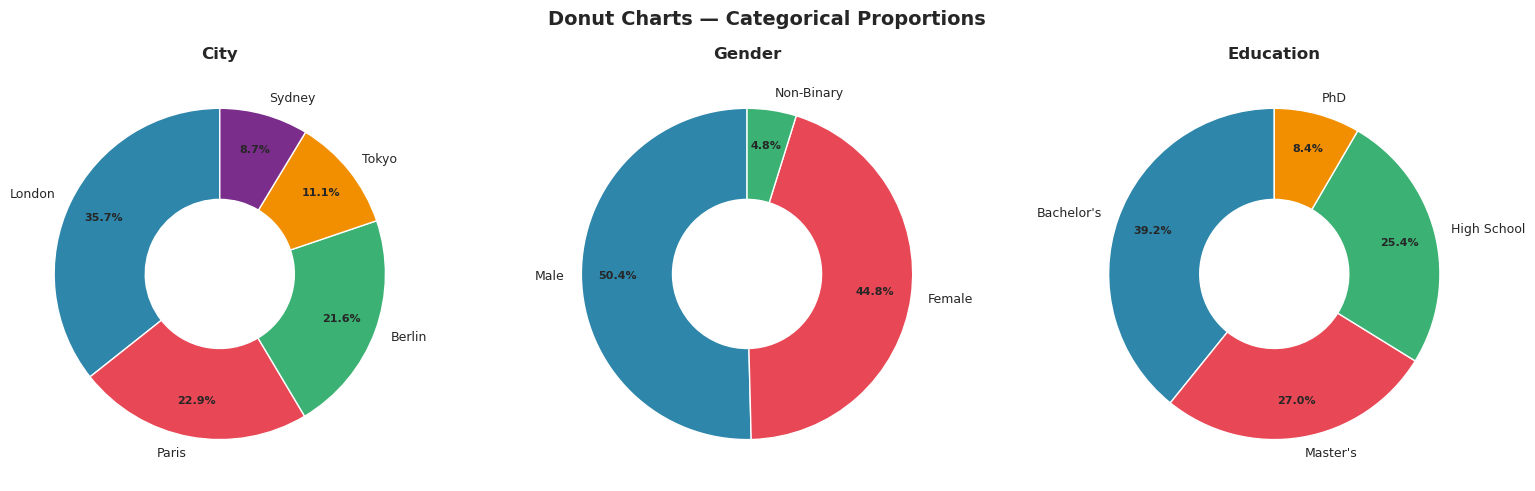

In [15]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts(dropna=True)
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=COLORS['palette'][:len(counts)],
        startangle=90,
        wedgeprops=dict(width=0.55),      # donut style
        textprops=dict(fontsize=9),
        pctdistance=0.78
    )
    for at in autotexts:
        at.set_fontsize(8)
        at.set_fontweight('bold')
    ax.set_title(col, fontsize=12, fontweight='bold')

plt.suptitle('Donut Charts — Categorical Proportions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 1️⃣1️⃣ Target Variable Analysis

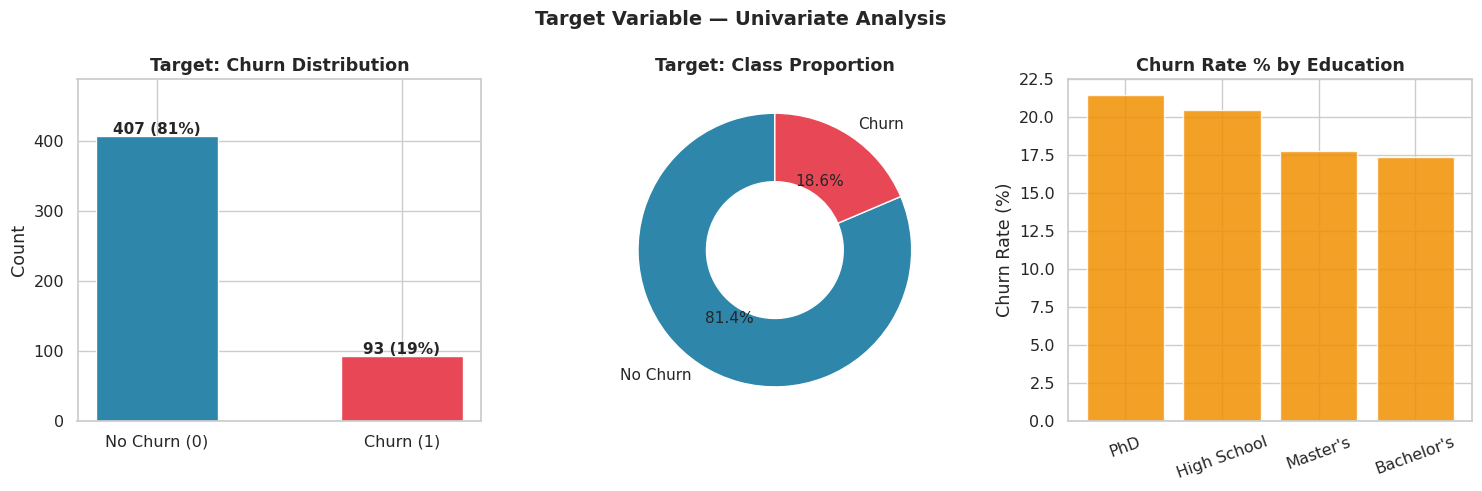

Class imbalance ratio: 4.4:1  (81% vs 19%)


In [16]:
target = 'Churn'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar chart
counts = df[target].value_counts().sort_index()
bars = axes[0].bar(['No Churn (0)', 'Churn (1)'],
                    counts.values,
                    color=[COLORS['primary'], COLORS['secondary']],
                    edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'{val} ({val/len(df)*100:.0f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Target: Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Donut
axes[1].pie(counts.values,
             labels=['No Churn', 'Churn'],
             autopct='%1.1f%%',
             colors=[COLORS['primary'], COLORS['secondary']],
             startangle=90,
             wedgeprops=dict(width=0.5),
             textprops=dict(fontsize=11))
axes[1].set_title('Target: Class Proportion', fontweight='bold')

# Count across Education
churn_by_edu = df.groupby('Education')[target].mean().sort_values(ascending=False)
axes[2].bar(churn_by_edu.index,
             churn_by_edu.values * 100,
             color=COLORS['warning'], edgecolor='white', alpha=0.85)
axes[2].set_title('Churn Rate % by Education', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Target Variable — Univariate Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {counts[0]/counts[1]:.1f}:1  '
      f'({counts[0]/len(df)*100:.0f}% vs {counts[1]/len(df)*100:.0f}%)')

---
## 📋 12. Automated Univariate EDA Report

In [17]:
def univariate_eda_report(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generates a complete univariate EDA report for all columns.
    Returns a DataFrame with key statistics and recommendations.
    """
    rows = []
    for col in df.columns:
        series  = df[col]
        is_num  = pd.api.types.is_numeric_dtype(series)
        missing = series.isnull().sum()

        row = {
            'Column'       : col,
            'Type'         : 'Numerical' if is_num else 'Categorical',
            'Non-Null'     : series.count(),
            'Missing'      : missing,
            'Missing %'    : round(missing / len(series) * 100, 2),
            'Unique Values': series.nunique(),
        }

        if is_num:
            row.update({
                'Mean'     : round(series.mean(), 4),
                'Median'   : round(series.median(), 4),
                'Std Dev'  : round(series.std(), 4),
                'Min'      : round(series.min(), 4),
                'Max'      : round(series.max(), 4),
                'IQR'      : round(series.quantile(0.75) - series.quantile(0.25), 4),
                'Skewness' : round(series.skew(), 4),
                'Kurtosis' : round(series.kurtosis(), 4),
                'Recommendation': (
                    'Log Transform — right-skewed' if series.skew() > 1 else
                    'Reflect + Log  — left-skewed' if series.skew() < -1 else
                    'Check outliers' if series.skew() > 0.5 else
                    'Normally distributed — OK'
                )
            })
        else:
            top_cat = series.value_counts().idxmax() if series.count() > 0 else 'N/A'
            row.update({
                'Mean'     : 'N/A', 'Median': 'N/A', 'Std Dev': 'N/A',
                'Min'      : 'N/A', 'Max'   : 'N/A', 'IQR'    : 'N/A',
                'Skewness' : 'N/A', 'Kurtosis': 'N/A',
                'Recommendation': (
                    'High cardinality — consider hashing/target encoding'
                    if series.nunique() > 20 else
                    'OHE if < 10 categories | Ordinal if ordered'
                )
            })
        rows.append(row)

    return pd.DataFrame(rows)


report = univariate_eda_report(df)
print('📋 Automated Univariate EDA Report:')
report

📋 Automated Univariate EDA Report:


,Column,Type,Non-Null,Missing,Missing %,Unique Values,Mean,Median,Std Dev,Min,Max,IQR,Skewness,Kurtosis,Recommendation
0,Age,Numerical,500,0,0.0000,52,44.2200,45.0000,15.0361,18,69,25.0000,-0.1127,-1.1070,Normally distributed — OK
1,Salary,Numerical,480,20,4.0000,479,101350.6292,102016.0000,45169.6147,25235.0000,179865.0000,75751.0000,-0.0015,-1.2237,Normally distributed — OK
2,Score,Numerical,500,0,0.0000,489,66.6527,66.0568,15.9497,23.2305,100.0000,21.6191,0.0378,-0.3666,Normally distributed — OK
3,Income,Numerical,500,0,0.0000,500,47101.3504,33394.0728,46282.2300,16.6281,269967.5927,49436.5816,1.8079,3.7592,Log Transform — right-skewed
4,Savings,Numerical,500,0,0.0000,500,9980.8256,10084.8961,2854.6743,-54.8316,18020.5329,3728.3797,-0.1064,0.2259,Normally distributed — OK
5,Debt,Numerical,500,0,0.0000,500,8041.6166,5162.7383,14611.4384,1613.1862,86813.0851,1493.7747,4.7194,20.6205,Log Transform — right-skewed
6,Num_Products,Numerical,500,0,0.0000,14,7.7060,8.0000,4.0955,1,14,7.0000,-0.0638,-1.2659,Normally distributed — OK
7,City,Categorical,485,15,3.0000,5,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,OHE if < 10 categories | Ordinal if ordered
8,Gender,Categorical,500,0,0.0000,3,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,OHE if < 10 categories | Ordinal if ordered
9,Education,Categorical,500,0,0.0000,4,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,OHE if < 10 categories | Ordinal if ordered


---
## ✅ 13. Summary & Best Practices

| Technique | Variable Type | Purpose |
|-----------|:-------------:|---------|
| **`df.describe()`** | Numerical | Summary statistics in one call |
| **Histogram + KDE** | Numerical | Distribution shape |
| **Box Plot** | Numerical | Outlier detection |
| **Violin Plot** | Numerical | Shape + summary combined |
| **Q-Q Plot** | Numerical | Normality check |
| **ECDF** | Numerical | Cumulative view |
| **Frequency Table** | Categorical | Counts & proportions |
| **Bar Chart** | Categorical | Category distribution |
| **Donut Chart** | Categorical | Proportional composition |

### 🔑 Golden Rules

1. **Always start with `isnull().sum()`** — understand missingness before statistics
2. **Use median, not mean, for skewed data** — mean is sensitive to outliers
3. **Plot histogram + KDE together** — histogram shows raw counts, KDE shows shape
4. **Run Q-Q plots before linear models** — they assume normality
5. **Avoid pie charts with > 5 categories** — use bar charts for precision
6. **Always check skewness** — skew > 1 or < -1 → apply log or power transform
7. **Check cardinality of categoricals** — high cardinality changes encoding strategy

---

## 🔗 Next Steps

- ➡️ `Bivariate_Analysis/` — Explore relationships **between** two variables
- ➡️ `Feature_Scaling/` — Use skewness insights to choose the right scaler
- ➡️ `Outlier_Detection/` — Deep-dive outlier removal after box plot screening
- ➡️ `Feature_Engineering/` — Apply log transform based on univariate findings